        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-06-29 02:55:13.779161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751145913.801340 1195841 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751145913.808200 1195841 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-29 02:55:13.831997: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [ ]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    # '/data1/kishoretarafdar/src.port/Volterra.mra.live/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu



2025-06-21 07:58:09.128267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750472889.149571 1311506 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750472889.156144 1311506 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-21 07:58:09.178633: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1750472891.351955 1311506 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


#  MIMO batch 

        export to py file

In [ ]:
import tensorflow as tf
import keras
from TFDWT.DWT3DFB import DWT3D, IDWT3D

@tf.keras.utils.register_keras_serializable()
class LSIVolterraMRAKernel3D(tf.keras.layers.Layer):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>. 
        
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
       Input: volumetric image x[n1,n2,n3]
       Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@03Jul2025"""
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        kernel_shape = (self.L, self.L, self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel')
        super().build(input_shape)
        
    def __makeH(self):
        paddings = [
            [0, self.N - self.L],  # depth dimension
            [0, self.N - self.L],  # height dimension
            [0, self.N - self.L],  # width dimension
            [0, 0],
            [0, 0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, n3, k1, k2, k3
        n1 = tf.range(self.N)  # depth indices
        n2 = tf.range(self.N)  # height indices
        n3 = tf.range(self.N)  # width indices
        k1 = tf.range(self.N)  # depth shift
        k2 = tf.range(self.N)  # height shift
        k3 = tf.range(self.N)  # width shift

        # meshgrid for all dims
        n1, n2, n3, k1, k2, k3 = tf.meshgrid(n1, n2, n3, k1, k2, k3, indexing='ij')  # Shape (N, N, N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Depth shift
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Height shift
        shifted_n3 = tf.math.mod(n3 - k3, self.N)  # Width shift

        # Gather the values from h1 using the shifted indices
        # h1: shape [N, N, N, ...]
        # Need to stack the indices as [shifted_n1, shifted_n2, shifted_n3]
        idx = tf.stack([shifted_n1, shifted_n2, shifted_n3], axis=-1)  # shape (..., 3)
        h1_shifted = tf.gather_nd(h1, idx)  # If h1 has more dimensions, ND gathers all trailing dims

        # h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234 ## very important line!!
        print('++', h1_shifted.shape)

        
        def dwtmra(h1_shifted):
            # ### second vectorized upgrade!! not matching
            # # h1_shifted: (N, N, N, N, in_channels, out_channels)
            N, in_channels, out_channels = self.N, self.channels, self.filters
            num_io = in_channels * out_channels

            # Flatten (in, out) for DWT2D
            hflat = tf.reshape(h1_shifted, (N, N, N, N, N, N, num_io))
            hflat_reshape = tf.reshape(hflat, (N*N*N, N, N, N, num_io))

            dwt3d = DWT3D(self.wave, clean=False)
            x1 = dwt3d(tf.cast(hflat_reshape, tf.float32))
            x1r = tf.reshape(x1, (N, N, N, N, N, N, num_io))

            # Transpose for columnplanewise DWT2D
            x1T = tf.transpose(x1r, [3, 4, 5, 0, 1, 2, 6])     # <--- This is the key fix
            x1T_reshape = tf.reshape(x1T, (N*N*N, N, N, N, num_io))
            x2 = dwt3d(x1T_reshape)
            x2r = tf.reshape(x2, (N, N, N, N, N, N, num_io))

            # Transpose back
            HT = tf.transpose(x2r, [3, 4, 5, 0, 1, 2, 6])
            HT = tf.reshape(HT, (N, N, N, N, N, N, in_channels, out_channels))
            return HT
        
        return dwtmra(h1_shifted)    

    def call(self, x):

        # HT = self.__getH()

        α = DWT3D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape

        H = self.__makeH()
        ## convolution like in wavelet domain
        β = tf.einsum('bijkc,uvwijkco->buvwco', α, H)
        β = tf.einsum('buvwco->buvwo',β)
        # β
        y = IDWT3D(self.wave, clean=False)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
        })
        return config

if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"  
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
    inputs = tf.keras.Input(shape=input_shape)
    # Apply the custom layer to the inputs
    H = LSIVolterraMRAKernel3D(filters=1)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 3D Random data
    inputs_data = tf.random.normal((1, N, N, N, 1))
    targets = tf.random.normal((1, N, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)
    

++ (4, 4, 4, 4, 4, 4, 1, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 4, 4, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra_mra_kernel3d_2     │ (None, 4, 4, 4, 1)     │            64 │
│ (LSIVolterraMRAKernel3D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
++ (4, 4, 4, 4, 4, 4, 1, 1)
++ (4, 4, 4, 4, 4, 4, 1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step - loss: 2.1717
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.1501
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.1288
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.1076
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.0867


In [ ]:
## Example
lay = LSIVolterraMRAKernel3D(filters=1)
import numpy as np
x = tf.cast(np.array([1.0,0,0,0,0,0,0,0]), tf.float32)
x = tf.einsum('i,j,k->ijk',x,x,x)
x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
x.shape, x.dtype
y = lay(x)
y.shape

In [3]:
lay.h1.numpy().shape

(4, 4, 4, 1, 1)

        matches with natuaral doman computation

In [4]:
wave = 'haar'

In [5]:
ch = 0 #check outchannel
h1 = lay.h1.numpy()[:,:,:,0,ch]

L = h1.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = x.shape[1]


paddings = [
                [0, Npoint - L],  # depth dimension
                [0, Npoint - L],  # height dimension
                [0, Npoint - L]  # width dimension
            ]
h1 = tf.pad(h1, paddings, mode='CONSTANT', constant_values=0)

# Create a meshgrid for n1, n2, n3, k1, k2, k3
n1 = tf.range(Npoint)  # depth indices
n2 = tf.range(Npoint)  # height indices
n3 = tf.range(Npoint)  # width indices
k1 = tf.range(Npoint)  # depth shift
k2 = tf.range(Npoint)  # height shift
k3 = tf.range(Npoint)  # width shift

# meshgrid for all dims
n1, n2, n3, k1, k2, k3 = tf.meshgrid(n1, n2, n3, k1, k2, k3, indexing='ij')  # Shape (N, N, N, N, N, N)

# Compute circularly shifted indices
shifted_n1 = tf.math.mod(n1 - k1, Npoint)  # Depth shift
shifted_n2 = tf.math.mod(n2 - k2, Npoint)  # Height shift
shifted_n3 = tf.math.mod(n3 - k3, Npoint)  # Width shift

# Gather the values from h1 using the shifted indices
# h1: shape [N, N, N, ...]
# Need to stack the indices as [shifted_n1, shifted_n2, shifted_n3]
idx = tf.stack([shifted_n1, shifted_n2, shifted_n3], axis=-1)  # shape (..., 3)
h1_shifted = tf.gather_nd(h1, idx)  # If h1 has more dimensions, ND gathers all trailing dims

h1_shifted.shape

# Result
print("Original h:")
# print(h1)
print("\nShape of h_shifted:", h1_shifted.shape)
# print("\nShifted h (first few elements):")
print(h1_shifted[0, 0, 0, 0:3, 0:3, 0:3].numpy())  # Example slice for visualization
# h_shifted.shape,# h_shifted[5,4,:,:]

ynat = tf.einsum('bijkc,uvwijk->buvwc', x, h1_shifted)#[0,:,:,:,0]
ynat.shape

Original h:

Shape of h_shifted: (8, 8, 8, 8, 8, 8)
[[[0.05671291 0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]]


TensorShape([1, 8, 8, 8, 1])

In [6]:
y.shape, ynat.shape

(TensorShape([1, 8, 8, 8, 1]), TensorShape([1, 8, 8, 8, 1]))

In [7]:
np.allclose(y, ynat, rtol=1e-05, atol=1e-08, equal_nan=False)

True

Volume range: -0.209 to 0.214 — using level=0.003
Volume range: -0.209 to 0.214 — using level=0.003


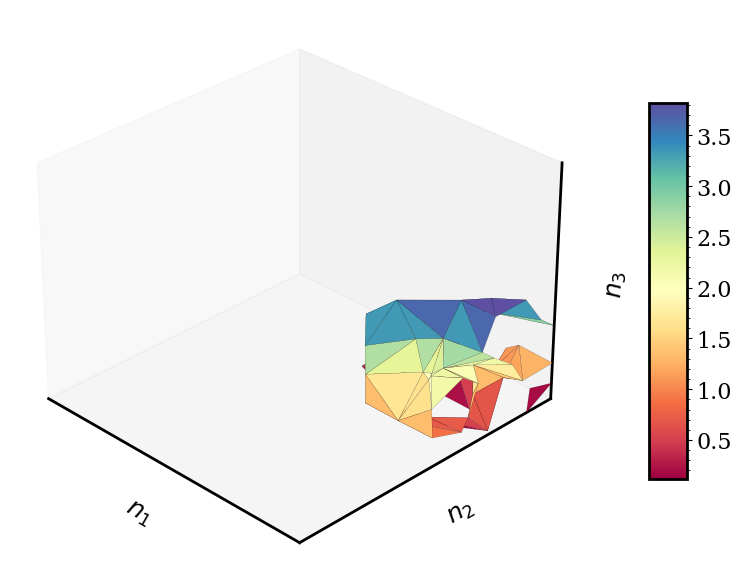

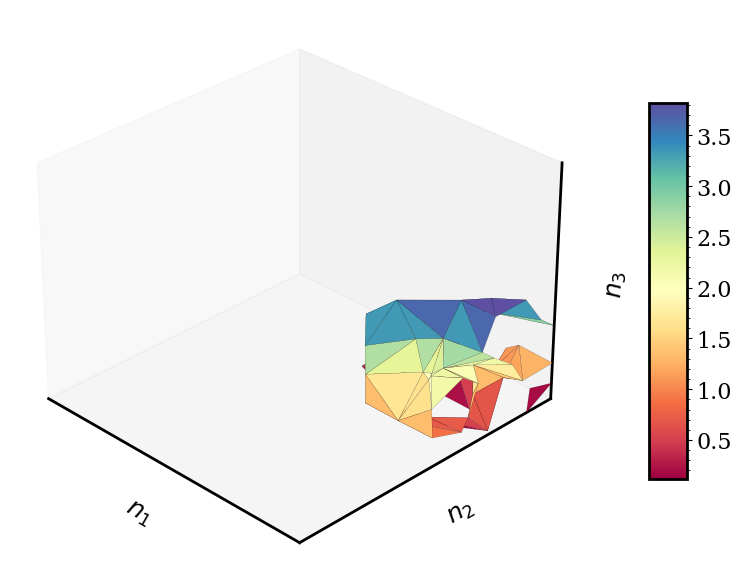

In [10]:
viz(tf.squeeze(ynat).numpy())
viz(tf.squeeze(y).numpy())

In [9]:
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import cm

# Set rcParams for publication-quality plots
plt.rcParams['figure.figsize'] = (10, 9)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.grid.which'] = 'both'
plt.rcParams['axes.linewidth'] = 2.0  
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['legend.fontsize'] = 16

def viz(volume, level=None, elev=30, azim=135, colormap=cm.Spectral):
    L = volume.shape[1]
    min_val = np.min(volume)
    max_val = np.max(volume)
    if level is None:
        level = (min_val + max_val) * 0.5

    print(f"Volume range: {min_val:.3f} to {max_val:.3f} — using level={level:.3f}")

    # Extract mesh with marching cubes
    verts, faces, _, _ = measure.marching_cubes(volume, level=level)
    face_colors = verts[faces][:, :, 2].mean(axis=1)
    norm = (face_colors - face_colors.min()) / (np.ptp(face_colors) + 1e-8)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(verts[faces], facecolors=colormap(norm), edgecolor='k', linewidths=0.1, alpha=1.0)
    ax.add_collection3d(mesh)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.set_xlabel('$n_1$')
    ax.set_ylabel('$n_2$')
    ax.set_zlabel('$n_3$')

    ax.view_init(elev=elev, azim=azim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    plt.tight_layout()

    # Optional: add colorbar
    mappable = cm.ScalarMappable(cmap=colormap)
    mappable.set_array(face_colors)
    plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, pad=0.1)


In [16]:
# ynat

In [21]:
# y[0,:,:,0], ynat[:,:]

In [18]:
# tolerance = 0.0001
# diff = tf.abs(ynat - y[0,:,:,0])
# are_equal_3dp = tf.reduce_all(diff < tolerance)

# print("Are tensors equal up to 3 decimal places?", are_equal_3dp.numpy())

In [19]:
# # Compute the absolute difference
# diff = tf.abs(ynat - y[0,:,:,0])

# # Compute norms
# numerator = tf.norm(diff)
# denominator = tf.norm(ynat)

# # Avoid division by zero
# percentage_error = tf.cond(
#     tf.equal(denominator, 0.0),
#     lambda: tf.constant(0.0),
#     lambda: (numerator / denominator) * 100
# )

# # Print the result
# print("Percentage error:", percentage_error.numpy(), "%")


In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)